### Import and Setup

In [1]:
import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath("../scr"))

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import seaborn as sns
import subprocess
import torch
import os
from scipy.stats import spearmanr
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast



from baseline_analysis import split_training_data
from utils import get_available_gpu, EarlyStopping

device = get_available_gpu()


Selected GPU: 4 | Memory Used: 17 MB
Selected GPU: 4 | Memory Used: 17 MB


### Define Simple CNN Model

In [2]:
def get_available_gpu():
    """
    Auto-detect the least busy GPU on the server and set it for torch.
    """
    try:
        # Query nvidia-smi for GPU utilization
        result = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=index,memory.used,memory.total", "--format=csv,nounits,noheader"],
            encoding="utf-8"
        )
        # Parse output
        gpu_stats = []
        for line in result.strip().split("\n"):
            index, mem_used, mem_total = map(int, line.split(","))
            gpu_stats.append((index, mem_used, mem_total))

        # Sort by least memory used
        gpu_stats.sort(key=lambda x: x[1])  # sort by mem_used

        # Pick first GPU
        best_gpu = gpu_stats[0][0]

        # Set CUDA_VISIBLE_DEVICES
        os.environ["CUDA_VISIBLE_DEVICES"] = str(best_gpu)
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

        print(f"Selected GPU: {best_gpu} | Memory Used: {gpu_stats[0][1]} MB")
        return device

    except Exception as e:
        print(f"GPU detection failed: {e}")
        print("Defaulting to CPU.")
        return torch.device("cpu")

# Example usage
device = get_available_gpu()

Selected GPU: 4 | Memory Used: 17 MB


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # No activation for regression
        return x


### Load data

In [4]:
image_directory = "/mnt/research-projects/j/jlgage/RawUAVData01/data/images"
csv_file = "/mnt/research-projects/j/jlgage/RawUAVData01/data/all_scored_images_clean.csv"

train_loader, val_loader, test_loader = split_training_data(image_directory, csv_file, batch_size=128)


2025-04-01 13:12:00,291 - baseline_analysis - INFO - Data split: Train=6881, Validation=1475, Test=1475


### Train model

/home/chhammet/miniforge3/envs/uav_regression_env/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_1059549/182811645.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


  0%|          | 0/27 [00:00<?, ?it/s]

/tmp/ipykernel_1059549/182811645.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1, Train Loss: 7.0393, Val Loss: 1.0242


  0%|          | 0/27 [00:00<?, ?it/s]

...

Epoch 6, Train Loss: 0.6814, Val Loss: 0.6092


  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 7, Train Loss: 0.6549, Val Loss: 0.6337


  0%|          | 0/27 [00:00<?, ?it/s]

Epoch 8, Train Loss: 0.6251, Val Loss: 0.6852
Early stopping triggered at epoch 8


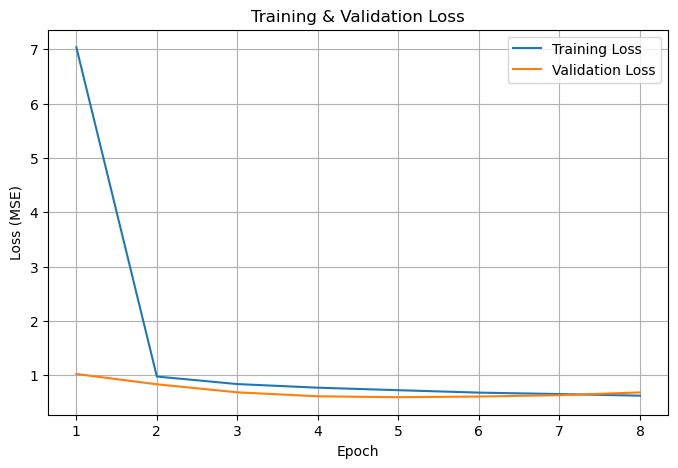

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
early_stopping = EarlyStopping(patience=3, min_delta=0.001)


num_epochs = 20

train_losses = []
val_losses = []

scaler = GradScaler()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    loop = tqdm(train_loader, leave=False)

    for images, scores in loop:
        images, scores = images.to(device), scores.to(device).unsqueeze(1)
        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, scores)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * images.size(0)
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, scores in val_loader:
            images, scores = images.to(device), scores.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, scores)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    early_stopping(val_loss)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()



### Evaluate Model

In [6]:
import numpy as np

model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for images, scores in val_loader:
        images, scores = images.to(device), scores.to(device).unsqueeze(1)
        outputs = model(images)
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(scores.cpu().numpy())

predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
print(f"Validation RMSE: {rmse:.4f}")


Validation RMSE: 1.3475


In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)
spearman_corr, p_value = spearmanr(actuals, predictions)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_value:.4f})")
print(f"Validation MAE: {mae:.4f}")
print(f"Validation R² Score: {r2:.4f}")

Spearman Correlation: 0.7042 (p-value: 0.0000)
Validation MAE: 1.0923
Validation R² Score: 0.2847


### Visualize

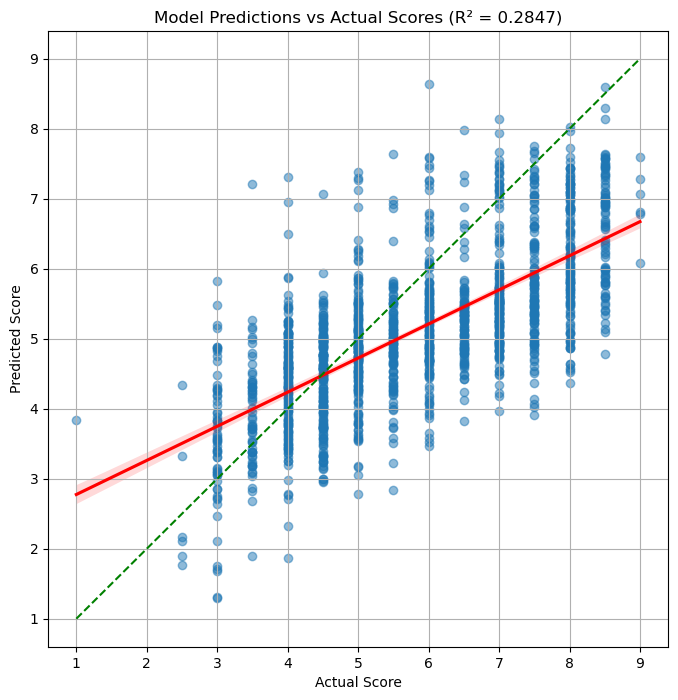

In [8]:
# Create data for visualization
df_results = pd.DataFrame({'Actual': actuals, 'Predicted': predictions})
df_results['Error'] = np.abs(df_results['Actual'] - df_results['Predicted'])

# Improved scatter plot
plt.figure(figsize=(8, 8))
sns.regplot(x='Actual', y='Predicted', data=df_results, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], color='green', linestyle='--')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Model Predictions vs Actual Scores (R² = {:.4f})'.format(r2))
plt.grid(True)
plt.show()

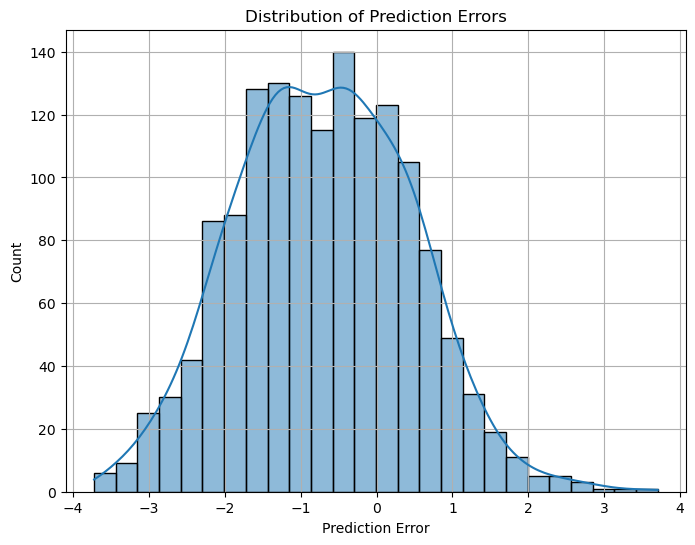

In [9]:
plt.figure(figsize=(8, 6))
residuals = predictions - actuals
sns.histplot(residuals, kde=True)
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.title('Distribution of Prediction Errors')
plt.grid(True)
plt.show()